## Results and Evaluation
**Purpose:** Evaluate and compare model behavior using exported artifacts from `03_modeling.ipynb`, with a consistent diagnostics layout across `U` linear, `V` linear, and `V` Random Forest.  
**Inputs:** `../data/processed/predictions_u_linear.csv`, `../data/processed/predictions_v_linear.csv`, `../data/processed/predictions_v_rf.csv`, `../data/processed/linear_u_coefficients.csv`, `../data/processed/linear_v_coefficients.csv`, optional `../data/processed/model_metrics.csv`, and `../data/processed/rf_v_feature_importance.csv`.  
**Outputs:** Model-comparison figures, residual diagnostics, compact summary tables, and final interpretation notes.


In [19]:
from IPython.display import display
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm

sns.set_style('white')
plt.rcParams['font.size'] = 28

base = Path('../data/processed')

pred_u = pd.read_csv(base / 'predictions_u_linear.csv')
pred_v_lin = pd.read_csv(base / 'predictions_v_linear.csv')
pred_v_rf = pd.read_csv(base / 'predictions_v_rf.csv')
fi = pd.read_csv(base / 'rf_v_feature_importance.csv')
coef_u_path = base / 'linear_u_coefficients.csv'
coef_v_path = base / 'linear_v_coefficients.csv'
coef_u = pd.read_csv(coef_u_path) if coef_u_path.exists() else pd.DataFrame()
coef_v = pd.read_csv(coef_v_path) if coef_v_path.exists() else pd.DataFrame()
metrics_path = base / 'model_metrics.csv'
metrics_df = pd.read_csv(metrics_path) if metrics_path.exists() else pd.DataFrame()

# Normalize prediction column names (current exports use actual/predicted)
def _normalize_pred_cols(df):
    rename_map = {}
    if 'y_true' in df.columns and 'actual' not in df.columns:
        rename_map['y_true'] = 'actual'
    if 'y_pred' in df.columns and 'predicted' not in df.columns:
        rename_map['y_pred'] = 'predicted'
    if rename_map:
        df = df.rename(columns=rename_map)
    return df

pred_u = _normalize_pred_cols(pred_u)
pred_v_lin = _normalize_pred_cols(pred_v_lin)
pred_v_rf = _normalize_pred_cols(pred_v_rf)

for _df in (pred_u, pred_v_lin, pred_v_rf):
    if 'residual' not in _df.columns:
        _df['residual'] = _df['actual'] - _df['predicted']

if not metrics_df.empty:
    display(metrics_df)

### 1) Unified diagnostic panels (test set)

This section reproduces the thesis-style diagnostics from modeling with the same visual structure:
- parity plot (`actual` vs `predicted`),
- residual histogram with normal overlay,
- residuals vs predicted (colored by `atom_i`),
- residual boxplot by element,
- right-side summary panel (metrics text for linear, feature-importance bar chart for RF).


In [20]:
def _strip_q_feature(name):
    """Remove statsmodels patsy-style Q('x') wrapper from coefficient names for plots."""
    s = str(name).strip()
    if s.startswith("Q('") and s.endswith("')"):
        return s[3:-2]
    if s.startswith('Q("') and s.endswith('")'):
        return s[3:-2]
    if s.startswith("Q(") and s.endswith(")"):
        inner = s[2:-1].strip()
        if len(inner) >= 2 and inner[0] in "\"'" and inner[-1] == inner[0]:
            return inner[1:-1]
        return inner
    return s


def plot_model_diagnostics(df, actual_label, pred_label, model_title, right_panel='text', fi_df=None, coef_df=None):
    y_true = df['actual'].reset_index(drop=True)
    y_pred = df['predicted'].reset_index(drop=True)
    residuals = (y_true - y_pred).reset_index(drop=True)

    atoms = pd.Index(df['atom_i'].dropna().astype(str).unique()) if 'atom_i' in df.columns else pd.Index([])
    palette = (sns.color_palette('tab20', 20) + sns.color_palette('tab20b', 20) + sns.color_palette('tab20c', 20))[:len(atoms)]
    color_map = dict(zip(atoms, palette))

    fig = plt.figure(figsize=(28, 12))
    gs = GridSpec(2, 3, figure=fig, width_ratios=[1.3, 1.3, 1.15], wspace=0.2, hspace=0.3)
    ax_parity = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[0, 1])
    ax_resid = fig.add_subplot(gs[1, 0])
    ax_box = fig.add_subplot(gs[1, 1])
    ax_right = fig.add_subplot(gs[:, 2])

    # Parity by atom_i (same style used in 03)
    if len(atoms):
        elem_i = df['atom_i'].astype(str).reset_index(drop=True)
        for atom in atoms:
            mask = (elem_i.values == atom)
            if mask.any():
                ax_parity.scatter(y_true[mask], y_pred[mask], color=color_map.get(atom, 'gray'), edgecolor='k', s=45, linewidths=0.5)
    else:
        ax_parity.scatter(y_true, y_pred, alpha=0.5, color='gray', edgecolor='k', s=45, linewidths=0.5)

    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax_parity.plot([lo, hi], [lo, hi], 'k--', lw=2, alpha=0.55)
    ax_parity.set_xlabel(actual_label)
    ax_parity.set_ylabel(pred_label)
    ax_parity.set_title(model_title)

    # Residual histogram
    sns.histplot(residuals, bins=20, kde=False, stat='density', color='skyblue', alpha=0.6, ax=ax_hist)
    mu, sigma = norm.fit(residuals)
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax_hist.plot(x, norm.pdf(x, mu, sigma), 'r--', lw=2)
    ax_hist.set_xlabel('Residuals (eV)')
    ax_hist.set_ylabel('Density (eV$^{-1}$)')

    # Residuals vs predicted + legend by atom_i
    if len(atoms):
        elem_i = df['atom_i'].astype(str).reset_index(drop=True)
        for atom in atoms:
            mask = (elem_i.values == atom)
            if mask.any():
                ax_resid.scatter(y_pred[mask], residuals[mask], color=color_map.get(atom, 'gray'), edgecolor='k', s=35, linewidths=0.5)
        handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[atom], markersize=8, label=atom, markeredgecolor='k', markeredgewidth=0.5)
                   for atom in atoms if (elem_i.values == atom).any()]
        ax_resid.legend(handles=handles, title='atom_i', loc='upper right', ncol=4, fontsize=14, title_fontsize=14, frameon=True, handletextpad=0.2)
    else:
        ax_resid.scatter(y_pred, residuals, alpha=0.5, color='darkorange', edgecolor='k', s=35)

    ax_resid.axhline(0, color='black', lw=0.9, linestyle='--')
    ax_resid.set_xlabel('Predicted (eV)')
    ax_resid.set_ylabel('Residuals (eV)')
    ax_resid.set_ylim(-5, 5)

    # Residual boxplot by element
    if 'atom_i' in df.columns and df['atom_i'].nunique() > 1:
        sns.boxplot(x=df['atom_i'].astype(str), y=residuals, ax=ax_box)
        ax_box.axhline(0, color='black', lw=0.9, linestyle='--')
        ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=90)
        ax_box.set_xlabel('Element')
        ax_box.set_ylabel('Residuals (eV)')
        ax_box.set_ylim(-5, 5)
    else:
        ax_box.text(0.5, 0.5, 'Single element (or unavailable)', ha='center', va='center', transform=ax_box.transAxes)
        ax_box.set_axis_off()

    # Right column: OLS coefficients (linear) | RF importances | fallback metrics text
    if right_panel == 'coefficients' and coef_df is not None and not coef_df.empty:
        cdf = coef_df.copy()
        if 'coefficient' not in cdf.columns and 'coef' in cdf.columns:
            cdf = cdf.rename(columns={'coef': 'coefficient'})
        cdf = cdf.sort_values('coefficient')
        cdf['feature'] = cdf['feature'].map(_strip_q_feature)
        yp = np.arange(len(cdf))
        ax_right.barh(yp, cdf['coefficient'].values, color='steelblue', edgecolor='k', height=0.7)
        ax_right.set_yticks(yp)
        ax_right.set_yticklabels(cdf['feature'].values, fontsize=22)
        ax_right.axvline(0, color='black', linewidth=0.9)
        ax_right.set_xlabel('Coefficient')
    elif right_panel == 'feature_importance' and fi_df is not None and not fi_df.empty:
        plot_df = fi_df.head(20).sort_values('importance', ascending=True)
        ax_right.barh(np.arange(len(plot_df)), plot_df['importance'].values, color='steelblue', edgecolor='k', height=0.7)
        ax_right.set_yticks(np.arange(len(plot_df)))
        ax_right.set_yticklabels(plot_df['feature'].values, fontsize=16)
        ax_right.axvline(0, color='black', linewidth=0.9)
        ax_right.set_xlabel('Feature Importance')
    else:
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
        mae = np.mean(np.abs(y_true - y_pred))
        ax_right.axis('off')
        ax_right.text(
            0.03, 0.95,
            f"{model_title}\n\nTest RMSE: {rmse:.4f}\nTest MAE: {mae:.4f}\nTest R²: {r2:.4f}",
            va='top', ha='left', fontsize=24
        )

    plt.tight_layout()
    plt.show()

/var/folders/dw/9pmjncps47q2gq34yw1xhwvw0000gn/T/ipykernel_33845/3608422308.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=90)
/var/folders/dw/9pmjncps47q2gq34yw1xhwvw0000gn/T/ipykernel_33845/3608422308.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


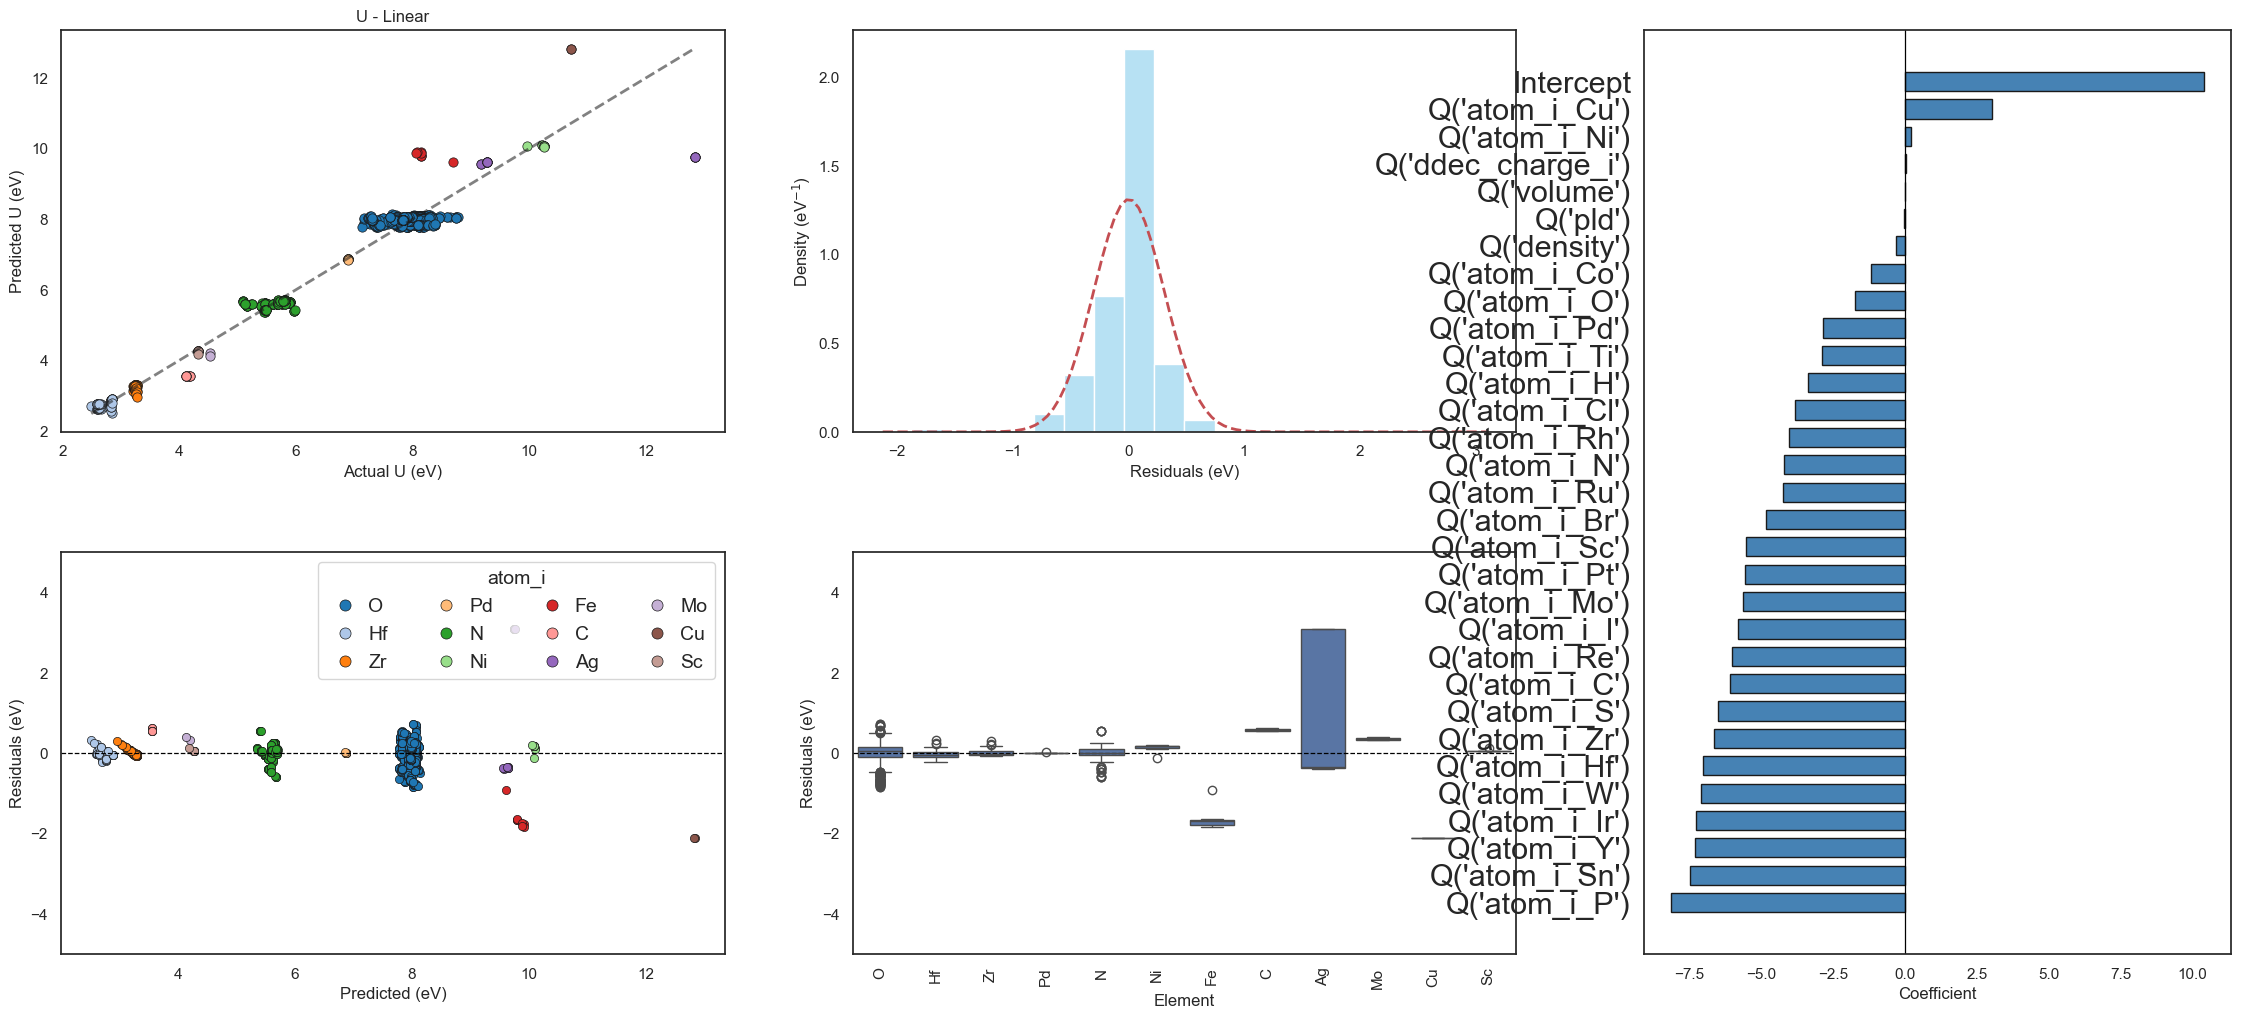

In [21]:
plot_model_diagnostics(pred_u, 'Actual U (eV)', 'Predicted U (eV)', 'U - Linear', right_panel='coefficients', coef_df=coef_u)


/var/folders/dw/9pmjncps47q2gq34yw1xhwvw0000gn/T/ipykernel_33845/3608422308.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=90)
/var/folders/dw/9pmjncps47q2gq34yw1xhwvw0000gn/T/ipykernel_33845/3608422308.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


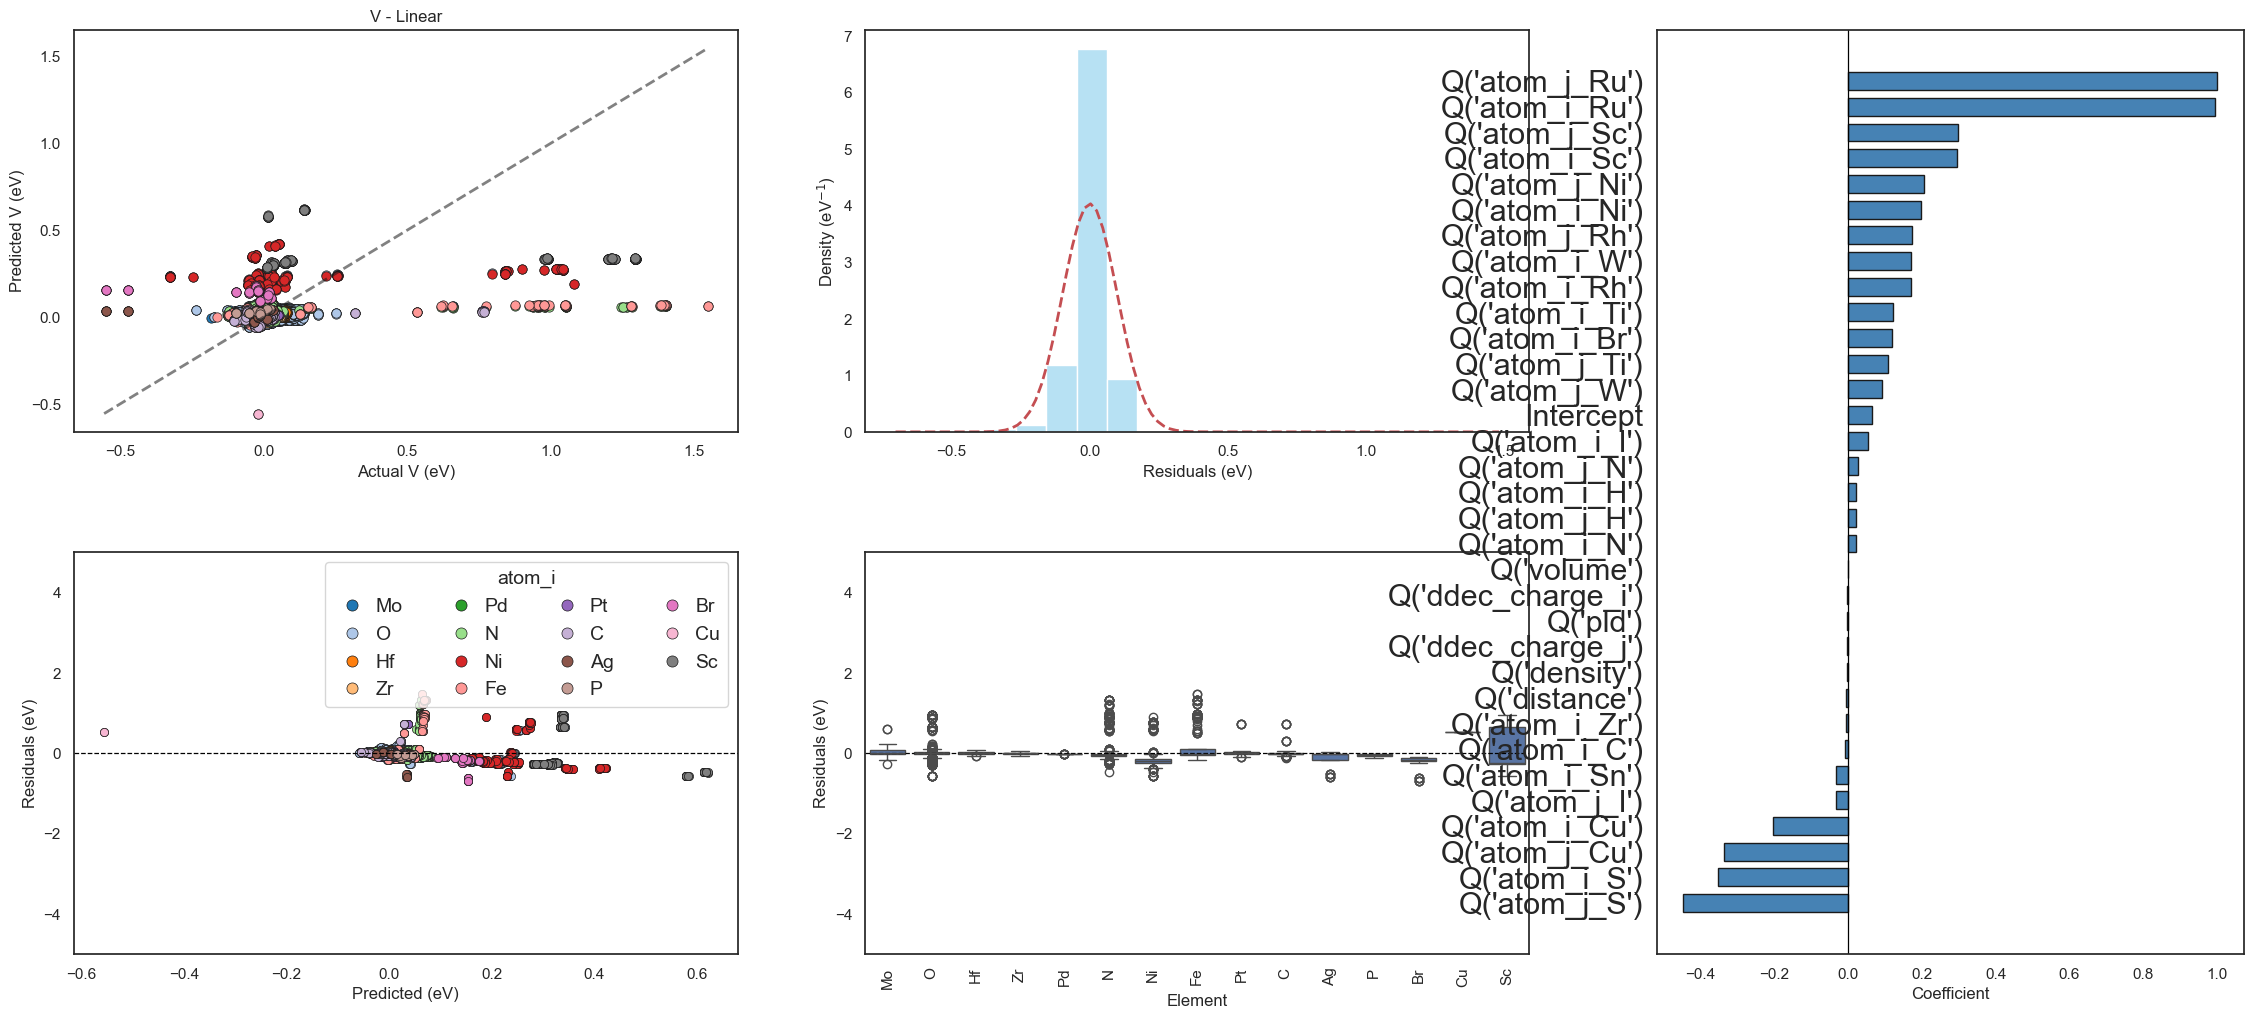

In [22]:
plot_model_diagnostics(pred_v_lin, 'Actual V (eV)', 'Predicted V (eV)', 'V - Linear', right_panel='coefficients', coef_df=coef_v)


/var/folders/dw/9pmjncps47q2gq34yw1xhwvw0000gn/T/ipykernel_33845/3608422308.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=90)
/var/folders/dw/9pmjncps47q2gq34yw1xhwvw0000gn/T/ipykernel_33845/3608422308.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


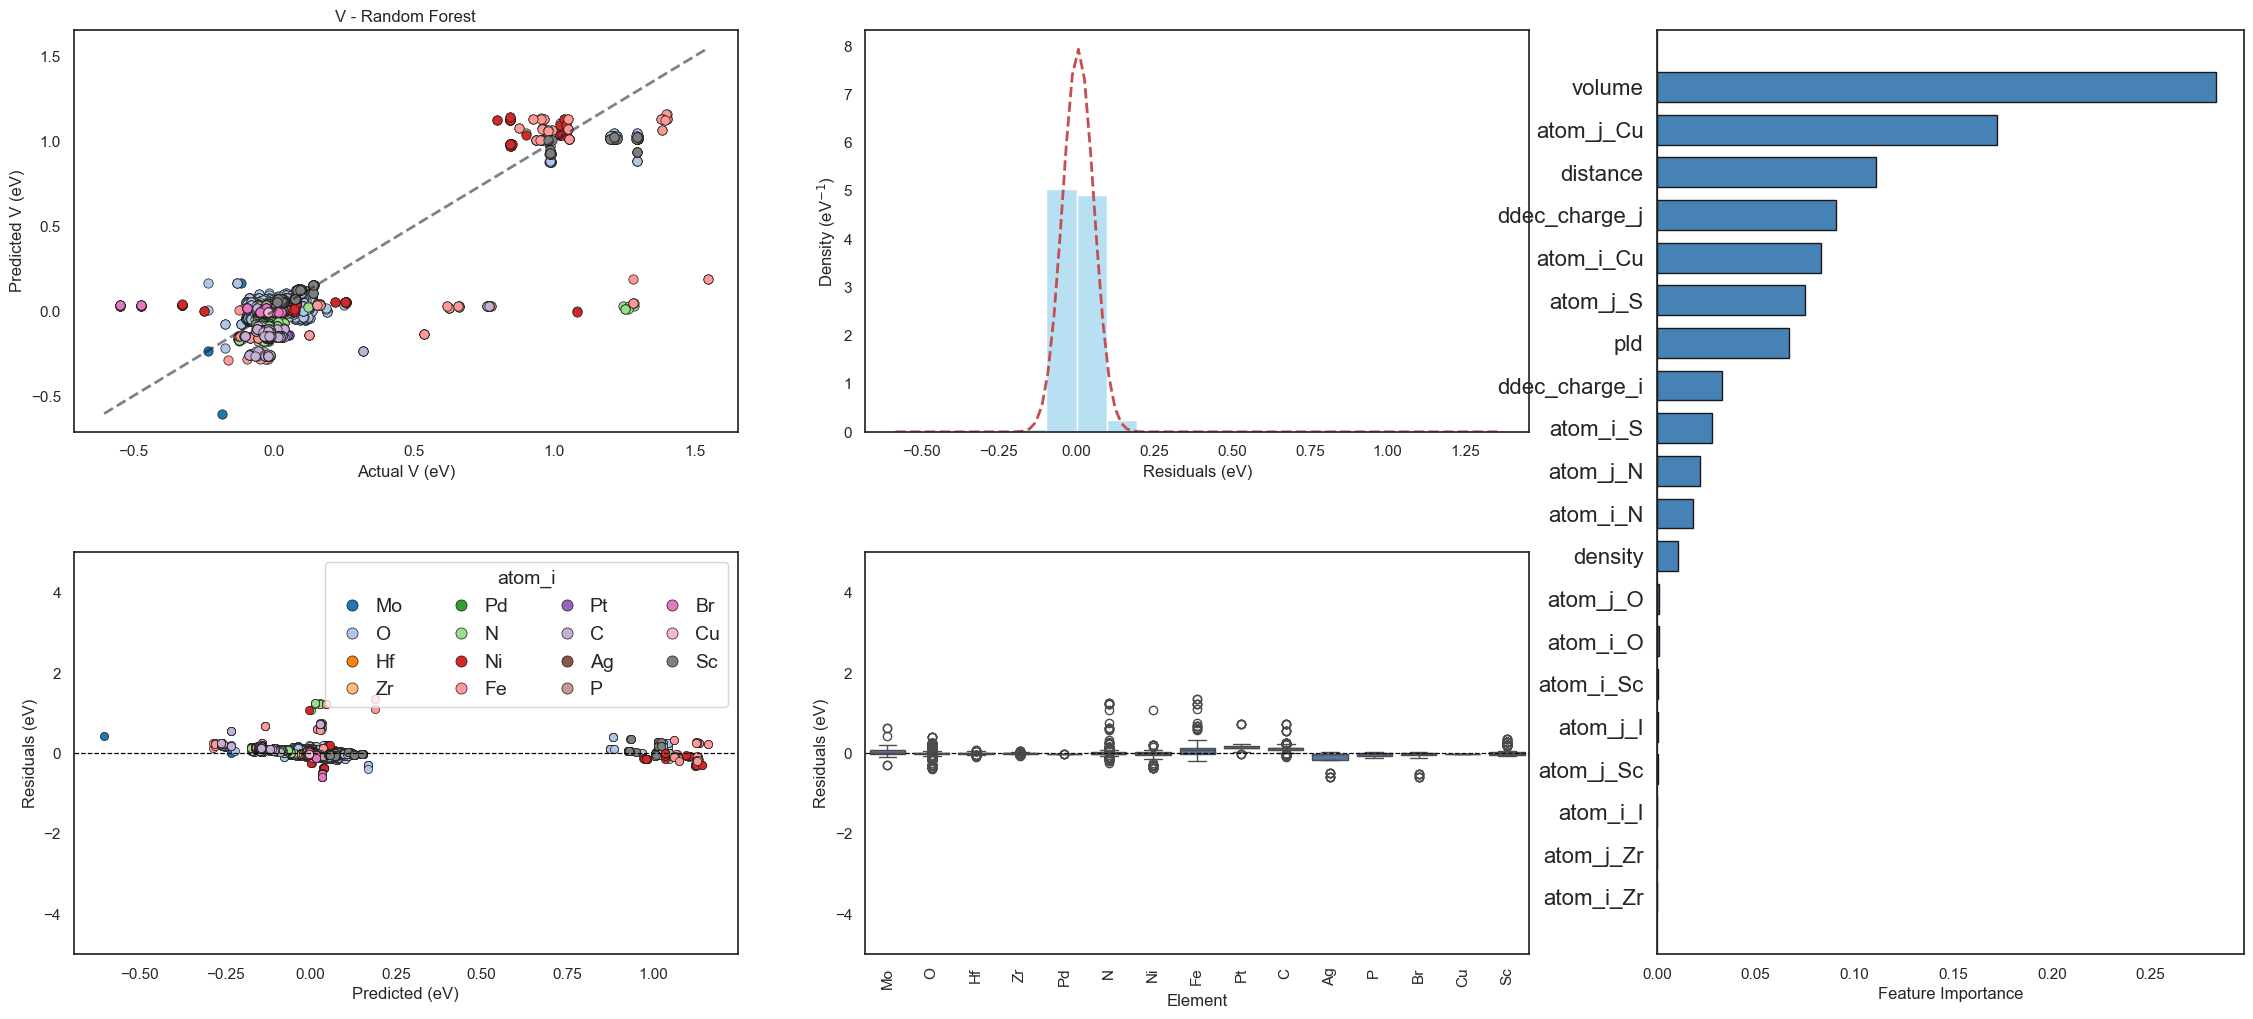

In [23]:
plot_model_diagnostics(pred_v_rf, 'Actual V (eV)', 'Predicted V (eV)', 'V - Random Forest', right_panel='feature_importance', fi_df=fi)

### 2) Consolidated metric comparison

Compute a compact test-only summary (`RMSE`, `MAE`, `R²`) directly from exported prediction files.

This table is intended to be the quick ranking view before writing the narrative conclusions.


In [24]:
# Consolidated test metrics (computed from exported predictions)
def _metrics_from_pred(df):
    y = df['actual'].to_numpy()
    p = df['predicted'].to_numpy()
    mse = np.mean((y - p) ** 2)
    return {
        'rmse_test': np.sqrt(mse),
        'mae_test': np.mean(np.abs(y - p)),
        'r2_test': 1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2),
    }

summary = pd.DataFrame([
    {'model': 'U_linear', **_metrics_from_pred(pred_u)},
    {'model': 'V_linear', **_metrics_from_pred(pred_v_lin)},
    {'model': 'V_random_forest', **_metrics_from_pred(pred_v_rf)},
]).sort_values('r2_test', ascending=False)

summary


,model,rmse_test,mae_test,r2_test
0,U_linear,0.304197,0.180634,0.969632
2,V_random_forest,0.050549,0.026257,0.782190
1,V_linear,0.098839,0.046828,0.167277


### 3) RF feature-importance reference

Keep a compact top-feature table for `V` Random Forest interpretation.

Use this output together with the RF right-panel chart in Section 1 to discuss dominant predictors and compare relative importance magnitudes.


In [25]:
# Keep a compact feature-importance table to accompany the RF right panel plot
fi.head(20)


,feature,importance
0,volume,0.283076
1,atom_j_Cu,0.172234
2,distance,0.111097
3,ddec_charge_j,0.090940
4,atom_i_Cu,0.082911
5,atom_j_S,0.075124
6,pld,0.067022
7,ddec_charge_i,0.033231
8,atom_i_S,0.027993
9,atom_j_N,0.021866


### Evaluation summary checklist

After running this notebook, document:

- which model is best on test metrics (`RMSE`, `MAE`, `R²`),
- whether parity clouds remain close to the diagonal,
- whether residual spread and bias are reduced in RF vs linear for `V`,
- which predictors dominate RF importance and whether they are physically plausible.

Use these outputs as the final evidence block for your project narrative and conclusions.
